In [11]:
import re
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
from typing import Optional, Tuple

In [12]:
DATA_DIR = Path("./data")

In [13]:
def find_newest_log_files(data_dir: Path) -> Tuple[Optional[Path], Optional[Path], Optional[str]]:
    """
    Finds the newest pair of event/object CSV files in a directory based
    on the timestamp in the filename.
    
    Filename format: YYYY-MM-DD_HH-MM-SS_ocel_name_(event|object).csv
    """
    
    # Regex to capture: 1:timestamp, 2:ocel_name, 3:type
    pattern = re.compile(r"(\d{4}-\d{2}-\d{2}_\d{2}-\d{2}-\d{2})_(.+)_(event|object)\.csv")    
    parsed_files = []
    for csv_file in data_dir.glob("*.csv"):
        match = pattern.match(csv_file.name)
        if match:
            timestamp, ocel_name, file_type = match.groups()
            parsed_files.append((timestamp, ocel_name, file_type, csv_file))
            
    if not parsed_files:
        print(f"Error: No matching log files found in {data_dir.resolve()}")
        return None, None, None
        
    # Find the latest timestamp (string comparison works for this format)
    latest_timestamp = max(item[0] for item in parsed_files)
    
    # Find the matching files for this exact timestamp
    event_file_info = next((item for item in parsed_files if item[0] == latest_timestamp and item[2] == 'event'), None)
    object_file_info = next((item for item in parsed_files if item[0] == latest_timestamp and item[2] == 'object'), None)
    
    if not event_file_info or not object_file_info:
        print(f"Error: Found timestamp {latest_timestamp}, but could not find a matching event/object file pair.")
        return None, None, None
        
    ocel_name = event_file_info[1]
    event_file_path = event_file_info[3]
    object_file_path = object_file_info[3]
    
    print(f"\nFound newest files for OCEL: '{ocel_name}' (Timestamp: {latest_timestamp})")
    print(f"Event file:   {event_file_path.name}")
    print(f"Object file:  {object_file_path.name}")
    
    return event_file_path, object_file_path, ocel_name

In [14]:
def remove_outliers(df: pd.DataFrame, column: str, n_std: float = 3.0) -> pd.DataFrame:
    """
    Removes outliers from a DataFrame based on the Z-score of a specific column.
    
    A Z-score measures how many standard deviations a data point is from the mean.
    
    Parameters:
    -----------
    df : pd.DataFrame
        The input DataFrame.
    column : str
        The name of the column to check for outliers (e.g., 'time').
    n_std : float
        The number of standard deviations to use as the threshold.
        Any row with a Z-score *absolute value* greater than this will be removed.
        A common value is 3.0.
        
    Returns:
    --------
    pd.DataFrame
        A new DataFrame with the outliers removed.
    """
    if df.empty or column not in df.columns:
        return df 
    
    # Calculate the mean and standard deviation
    col_mean = df[column].mean()
    col_std = df[column].std()

    # Avoid division by zero if standard deviation is 0
    if col_std == 0:
        return df
        
    # Calculate the Z-score for each data point in the column
    z_scores = (df[column] - col_mean) / col_std
    
    # Create a boolean mask for all rows where the Z-score is within the threshold
    is_not_outlier = z_scores.abs() <= n_std
    
    # Return the filtered DataFrame
    return df[is_not_outlier]

In [15]:
def plot_timing_chart(ax: plt.Axes, 
                      df: pd.DataFrame, 
                      x_col: str, 
                      y_col: str, 
                      x_label: str,
                      filter_fitting: Optional[bool] = None,
                      style_by_fitting: bool = False,
                      color_by_col: Optional[str] = None):
    """
    Plots a scatter chart with optional filtering, styling, and coloring.
    """
    # --- 1. Data Validation & Filtering ---
    if df.empty or x_col not in df.columns or y_col not in df.columns:
        ax.text(0.5, 0.5, "Data missing", ha='center', va='center', color='red')
        return

    # Filter by 'fitting' if requested
    # If filter_fitting is True, keep only True. If False, keep only False. If None, keep all.
    if filter_fitting is not None:
        if 'fitting' not in df.columns:
            print("Warning: 'fitting' column missing. Cannot filter.")
        else:
            df = df[df['fitting'] == filter_fitting]
            if df.empty:
                ax.text(0.5, 0.5, f"No data for fitting={filter_fitting}", ha='center', va='center')
                return

    # --- 2. Setup Colors (Hue) ---
    c_mapping = None
    cmap = None
    norm = None
    
    if color_by_col:
        if color_by_col in df.columns:
            c_mapping = df[color_by_col]
            cmap = 'viridis' # A perceptually uniform colormap
            # We capture min/max to ensure consistent coloring across markers
            norm = plt.Normalize(df[color_by_col].min(), df[color_by_col].max())
        else:
            print(f"Warning: Color column '{color_by_col}' not found.")
            c_mapping = 'blue' # Fallback
    else:
        c_mapping = 'blue' # Default color

    # --- 3. Plotting Logic ---
    
    # CASE A: Different Shapes for Fitting (True=Circle, False=X)
    if style_by_fitting and 'fitting' in df.columns:
        
        # Define styles
        # 'o' = circle, 'x' = cross
        styles = {True: 'o', False: 'x'}
        labels = {True: 'Fitting', False: 'Not Fitting'}
        
        # We must plot subsets to assign different markers
        for is_fitting, marker in styles.items():
            subset = df[df['fitting'] == is_fitting]
            if subset.empty:
                continue
                
            # If we are coloring by a column, we must use the correct subset of values
            c_subset = subset[color_by_col] if (color_by_col and color_by_col in subset.columns) else 'blue'
            
            sc = ax.scatter(subset[x_col], 
                            subset[y_col], 
                            marker=marker,
                            c=c_subset,
                            cmap=cmap,
                            norm=norm, # Ensure color scale is shared between subsets
                            alpha=0.5, 
                            label=labels[is_fitting])
            
        ax.legend(loc='upper right')

    # CASE B: Standard Plot (Same shape for all)
    else:
        sc = ax.scatter(df[x_col], 
                        df[y_col], 
                        marker='o', 
                        c=c_mapping, 
                        cmap=cmap,
                        norm=norm,
                        alpha=0.5)

    # --- 4. Add Colorbar if coloring by column ---
    if color_by_col and cmap:
        # Create a ScalarMappable to generate the colorbar (needed because we might have multiple scatter calls)
        sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
        sm.set_array([])
        plt.colorbar(sm, ax=ax, label=color_by_col)

    # --- 5. Labels and Grid ---
    ax.set_xlabel(x_label, fontsize=12)
    ax.set_ylabel("Time (s)", fontsize=12)
    ax.grid(True, linestyle='--', alpha=0.6)

In [16]:
def create_comparison_plots(event_df: pd.DataFrame, 
                            object_df: pd.DataFrame, 
                            ocel_name: str, 
                            plot_title_suffix: str = "",
                            **kwargs): # <--- Added **kwargs to pass arguments through
    """
    Generates side-by-side plots, passing optional args to the plotter.
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    fig.suptitle(f"Timing Analysis: {ocel_name}{plot_title_suffix}", fontsize=16)
    
    # Pass **kwargs (e.g., color_by_col="call_count") to the plotter
    plot_timing_chart(ax=ax1, 
                      df=event_df, 
                      x_col='no_events', 
                      y_col='time', 
                      x_label='Number of Events',
                      **kwargs) 
    
    plot_timing_chart(ax=ax2, 
                      df=object_df, 
                      x_col='no_objects', 
                      y_col='time', 
                      x_label='Number of Objects',
                      **kwargs)
    
    plt.tight_layout(rect=[0, 0.03, 1, 0.95]) 
    plt.show()


Found newest files for OCEL: 'Road_Traffic_Fine_Management_Process.xes' (Timestamp: 2025-11-26_13-32-35)
Event file:   2025-11-26_13-32-35_Road_Traffic_Fine_Management_Process.xes_event.csv
Object file:  2025-11-26_13-32-35_Road_Traffic_Fine_Management_Process.xes_object.csv

Successfully loaded 150370 event data points.
Successfully loaded 150370 object data points.

--- 1. Displaying Plots for Original Data ---


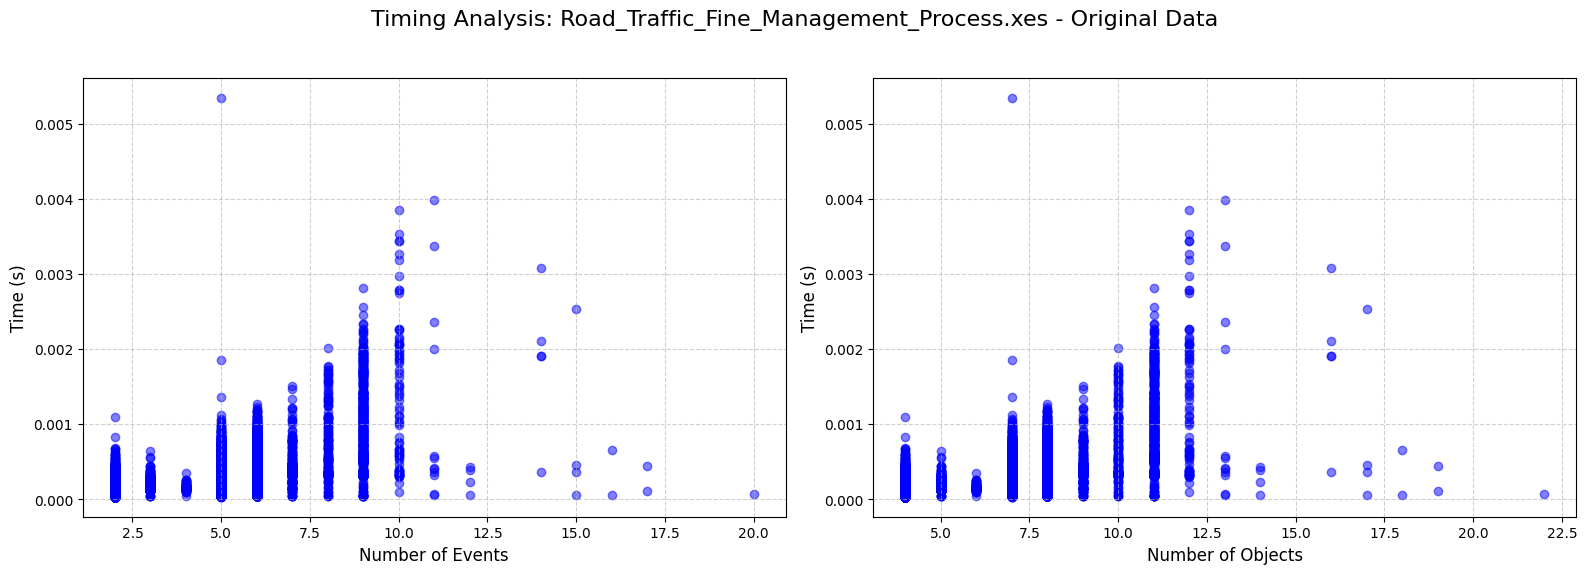


--- Removing Outliers (Threshold: 3.0 std dev on 'time') ---
Removed 1432 outliers from event data.
Removed 1432 outliers from object data.

--- 2. Displaying Plots for Filtered Data (Standard) ---


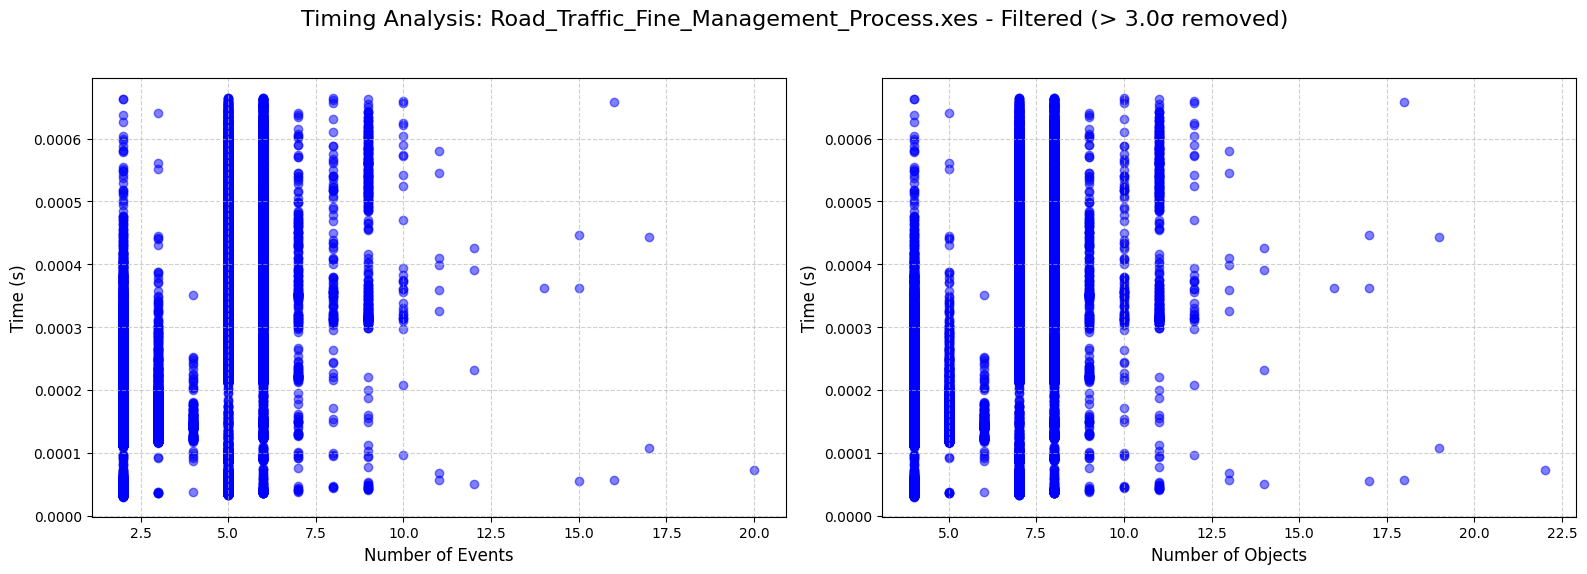


--- 3. Filtered Data (Fitting=True Only) ---


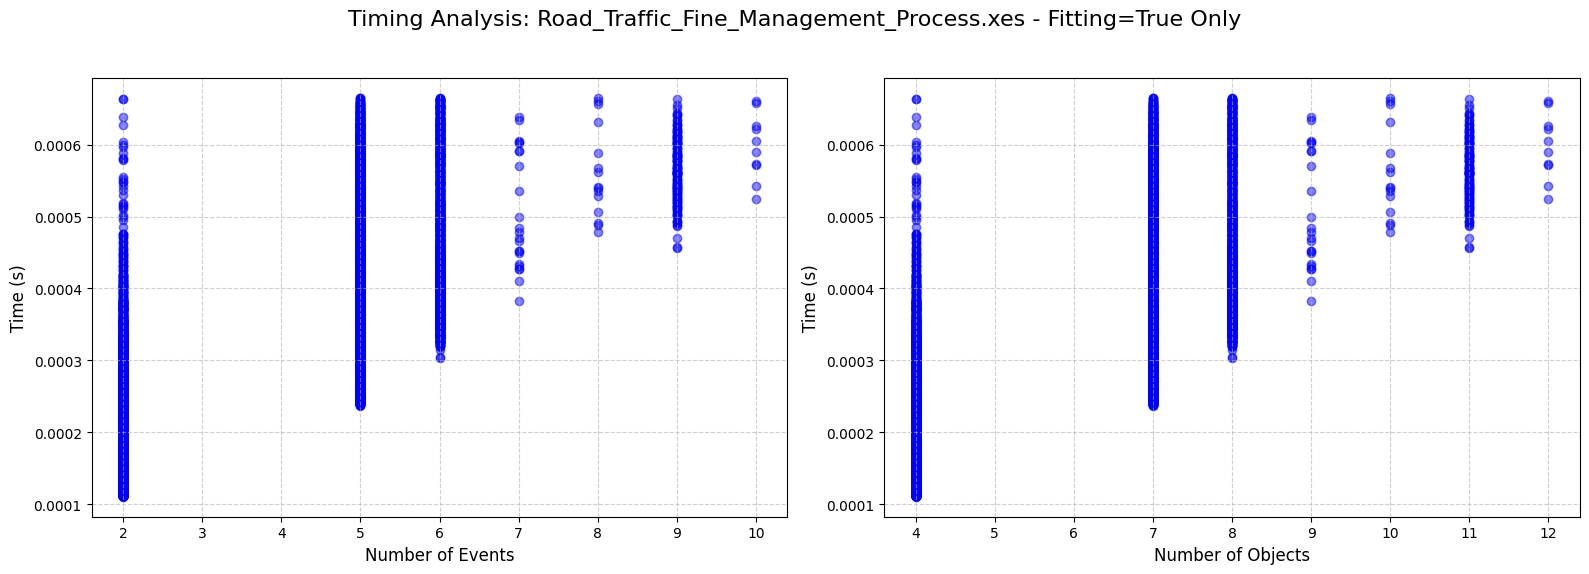


--- 4. Filtered Data (Fitting=False Only) ---


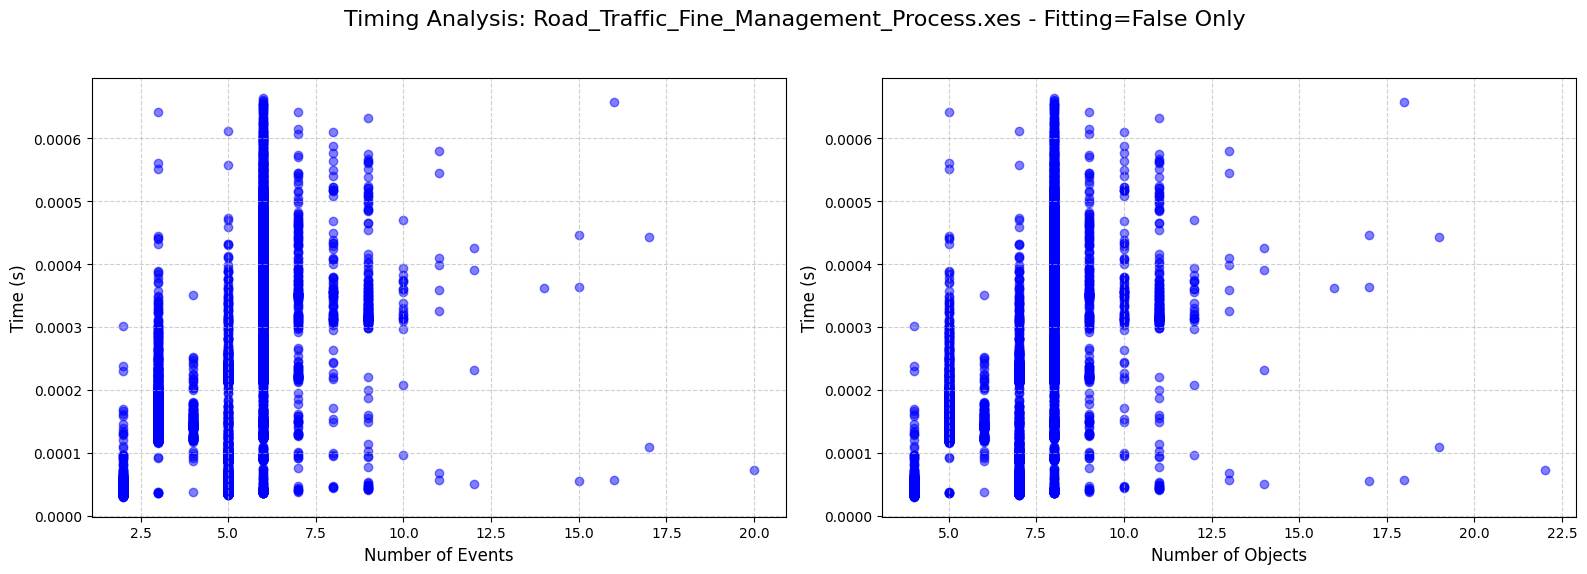


--- 5. Color depends on Fitting ---


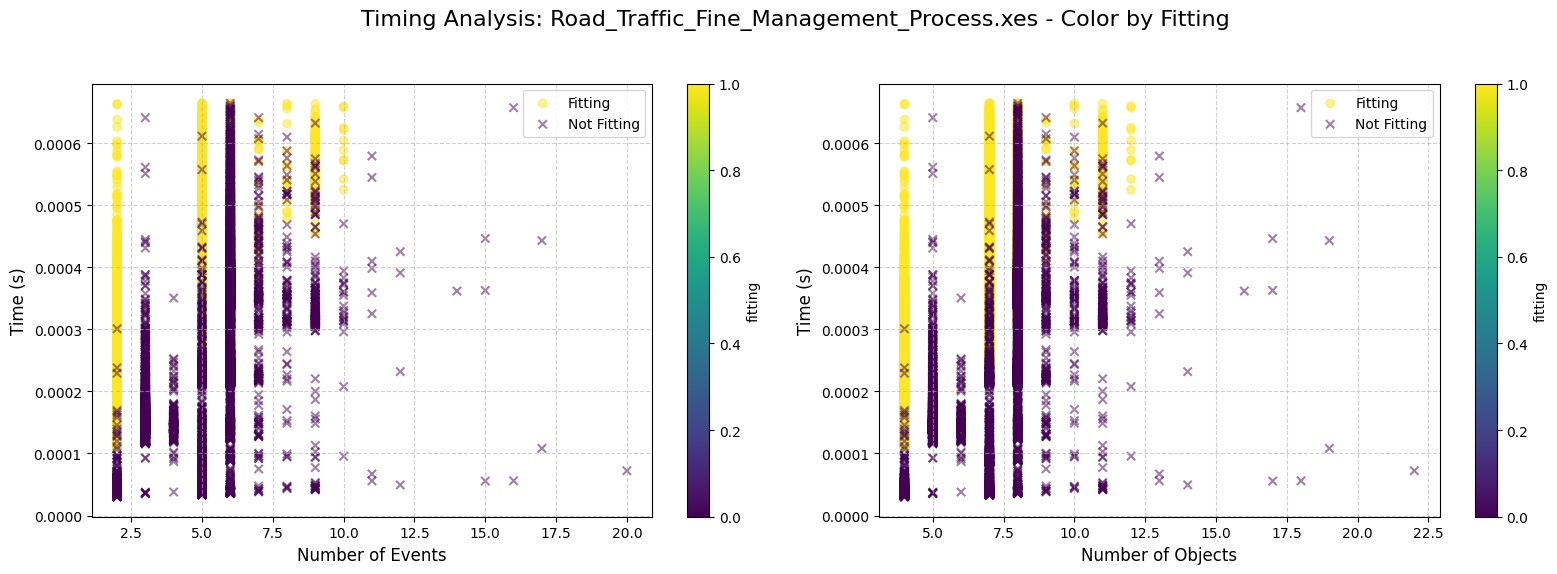


--- 6. Color depends on Call Count ---


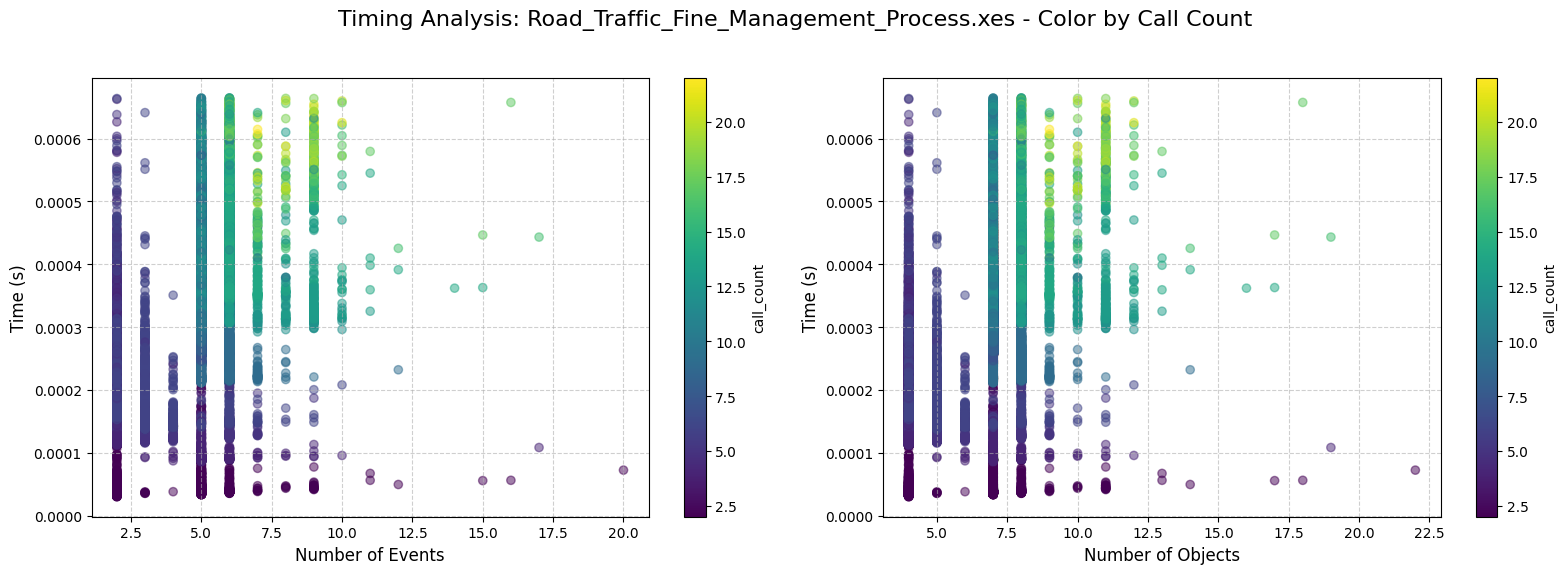


--- 7. Shape by Fitting AND Color by Call Count ---


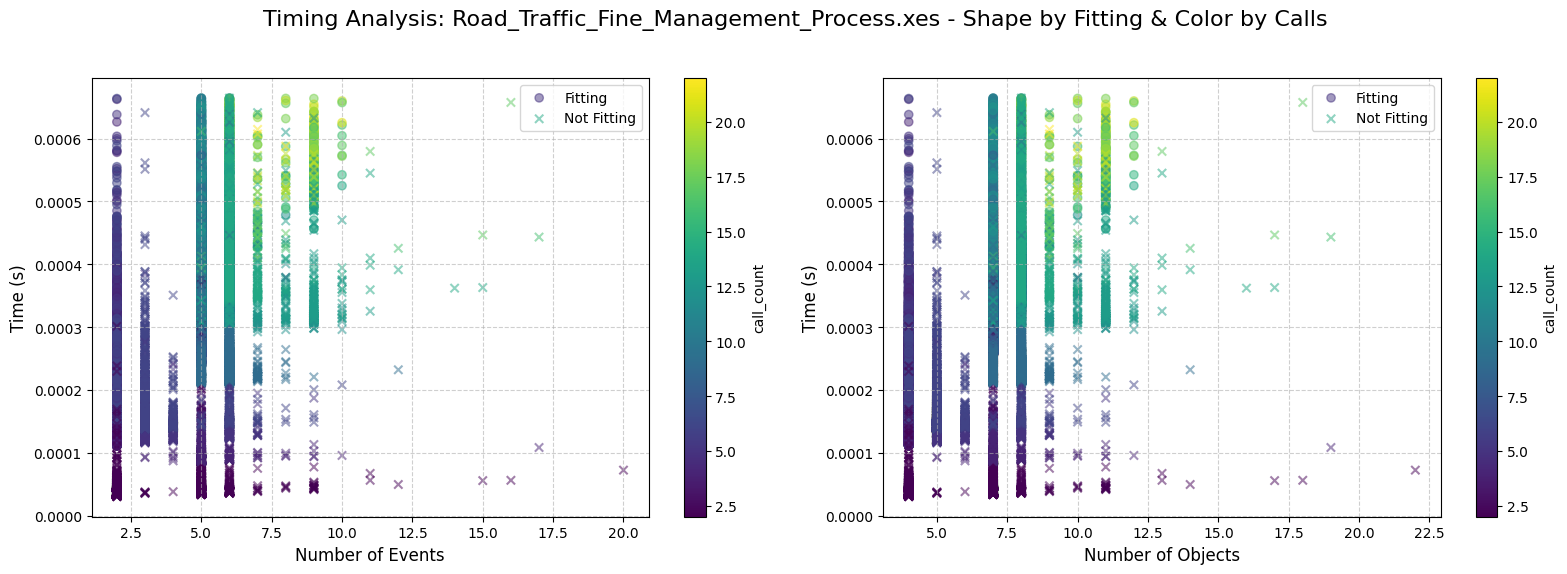


--- 8. Correlation: Time vs Call Count (Events Only) ---


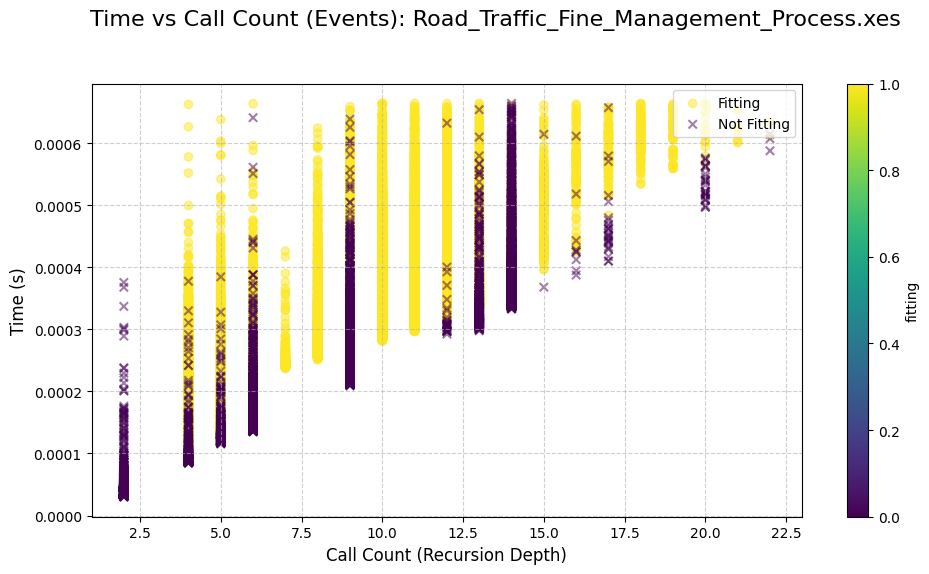

In [17]:
# --- 0. Parameters ---
# Threshold for outlier removal (default: 3.0 standard deviations)
OUTLIER_THRESHOLD_STD = 3.0

# --- 1. Find and Load Data ---
event_file, object_file, ocel_name = find_newest_log_files(DATA_DIR)

if event_file and object_file:
    try:
        event_df = pd.read_csv(event_file)
        object_df = pd.read_csv(object_file)
        
        print(f"\nSuccessfully loaded {len(event_df)} event data points.")
        print(f"Successfully loaded {len(object_df)} object data points.")

        # --- 2. Plot Original Data ---
        print("\n--- 1. Displaying Plots for Original Data ---")
        create_comparison_plots(event_df, 
                                object_df, 
                                ocel_name, 
                                plot_title_suffix=" - Original Data")

        # --- 3. Remove Outliers ---
        print(f"\n--- Removing Outliers (Threshold: {OUTLIER_THRESHOLD_STD} std dev on 'time') ---")
        
        event_df_filtered = remove_outliers(event_df, 'time', n_std=OUTLIER_THRESHOLD_STD)
        object_df_filtered = remove_outliers(object_df, 'time', n_std=OUTLIER_THRESHOLD_STD)
        
        event_rows_removed = len(event_df) - len(event_df_filtered)
        object_rows_removed = len(object_df) - len(object_df_filtered)
        
        print(f"Removed {event_rows_removed} outliers from event data.")
        print(f"Removed {object_rows_removed} outliers from object data.")
        
        # Update variables to use filtered data for all subsequent plots
        event_df = event_df_filtered
        object_df = object_df_filtered

        # --- 4. Plot Filtered Data (Standard) ---
        print("\n--- 2. Displaying Plots for Filtered Data (Standard) ---")
        create_comparison_plots(event_df, 
                                object_df, 
                                ocel_name, 
                                plot_title_suffix=f" - Filtered (> {OUTLIER_THRESHOLD_STD}σ removed)")

        # --- 5. Plot fitting=True ONLY ---
        print("\n--- 3. Filtered Data (Fitting=True Only) ---")
        create_comparison_plots(event_df, object_df, ocel_name, " - Fitting=True Only",
                                filter_fitting=True)

        # --- 6. Plot fitting=False ONLY ---
        print("\n--- 4. Filtered Data (Fitting=False Only) ---")
        create_comparison_plots(event_df, object_df, ocel_name, " - Fitting=False Only",
                                filter_fitting=False)

        # --- 7. Shape depends on fitting ---
        print("\n--- 5. Color depends on Fitting ---")
        create_comparison_plots(event_df, object_df, ocel_name, " - Color by Fitting",
                                color_by_col="fitting", style_by_fitting=True)

        # --- 8. Hue depends on call_count ---
        print("\n--- 6. Color depends on Call Count ---")
        create_comparison_plots(event_df, object_df, ocel_name, " - Color by Call Count",
                                color_by_col="call_count")

        # --- 9. Both (Shape=Fitting, Color=Call Count) ---
        print("\n--- 7. Shape by Fitting AND Color by Call Count ---")
        create_comparison_plots(event_df, object_df, ocel_name, " - Shape by Fitting & Color by Calls",
                                style_by_fitting=True,
                                color_by_col="call_count")

        # --- 10. NEW: Time vs Call Count (Events Only) ---
        print("\n--- 8. Correlation: Time vs Call Count (Events Only) ---")
        # Create a single plot (not side-by-side)
        fig, ax = plt.subplots(figsize=(10, 6))
        fig.suptitle(f"Time vs Call Count (Events): {ocel_name}", fontsize=16)
        
        plot_timing_chart(ax=ax,
                          df=event_df,
                          x_col='call_count',
                          y_col='time',
                          x_label='Call Count (Recursion Depth)',
                          # Optional: fitting info on this plot too
                          style_by_fitting=True, 
                          color_by_col='fitting'
                          )
        
        plt.tight_layout(rect=[0, 0.03, 1, 0.95])
        plt.show()

    except Exception as e:
        print(f"An error occurred while loading or plotting data: {e}")
        import traceback
        traceback.print_exc()
else:
    print("\nAborting: Could not find the necessary event and object files.")